In [1]:
# Install required packages for the project
import sys
import subprocess

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "scikit-learn",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

0

In [2]:
# Data Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Dataset loading, preprocessing, and data exploration
subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo"])

0

In [4]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset
rice_cammeo_and_osmancik = fetch_ucirepo(id=545)

# Use the raw table to avoid malformed all-NaN feature columns in data.features
df_raw = rice_cammeo_and_osmancik.data.original.copy()
X = df_raw.drop(columns=["Class"])
y = df_raw[["Class"]]

In [5]:
# Check available raw data payloads from ucimlrepo object
print('Has original:', hasattr(rice_cammeo_and_osmancik.data, 'original'))
orig = rice_cammeo_and_osmancik.data.original
print('Original type:', type(orig))
print('Original shape:', getattr(orig, 'shape', None))
if hasattr(orig, 'head'):
    print(orig.head(2))

Has original: True
Original type: <class 'pandas.DataFrame'>
Original shape: (3810, 8)
    Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  15231  525.578979         229.749878          85.093788      0.928882   
1  14656  494.311005         206.020065          91.730972      0.895405   

   Convex_Area    Extent   Class  
0        15617  0.572896  Cammeo  
1        15072  0.615436  Cammeo  


In [6]:
# Metadata 
print(rice_cammeo_and_osmancik.metadata) 

{'uci_id': 545, 'name': 'Rice (Cammeo and Osmancik)', 'repository_url': 'https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik', 'data_url': 'https://archive.ics.uci.edu/static/public/545/data.csv', 'abstract': "A total of 3810 rice grain's images were taken for the two species, processed and feature inferences were made. 7 morphological features were obtained for each grain of rice.", 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 3810, 'num_features': 7, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5MW4Z', 'creators': [], 'intro_paper': {'ID': 276, 'type': 'NATIVE', 'title': 'Classification of Rice Varieties Using Artificial Intelligence Methods', 'authors': 'Ilkay Cinar, M. Koklu', 'venue': 'International Journal of Intel

In [7]:
# Variable information 
print(rice_cammeo_and_osmancik.variables) 

                name     role        type demographic  \
0               Area  Feature     Integer        None   
1          Perimeter  Feature  Continuous        None   
2  Major_Axis_Length  Feature  Continuous        None   
3  Minor_Axis_Length  Feature  Continuous        None   
4       Eccentricity  Feature  Continuous        None   
5        Convex_Area  Feature     Integer        None   
6             Extent  Feature  Continuous        None   
7              Class   Target      Binary        None   

                                         description units missing_values  
0  Returns the number of pixels within the bounda...    px             no  
1  Calculates the circumference by calculating th...    px             no  
2  The longest line that can be drawn on the rice...   NaN             no  
3  The shortest line that can be drawn on the ric...   NaN             no  
4  It measures how round the ellipse, which has t...   NaN             no  
5  Returns the pixel count of 

In [8]:
X.head(10)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024
5,13479,477.015991,200.053055,86.650291,0.901328,13786,0.657897
6,15757,509.281006,207.296677,98.336136,0.880323,16150,0.589708
7,16405,526.570007,221.612518,95.436707,0.902521,16837,0.658888
8,14534,483.640991,196.650818,95.050682,0.875429,14932,0.649651
9,13485,471.570007,198.272644,87.727287,0.896789,13734,0.572320


In [9]:
y.head(10)

,Class
0,Cammeo
1,Cammeo
2,Cammeo
3,Cammeo
4,Cammeo
5,Cammeo
6,Cammeo
7,Cammeo
8,Cammeo
9,Cammeo


In [10]:
# Shape of the dataset
print(f"{X.shape=}, {y.shape=}")

X.shape=(3810, 7), y.shape=(3810, 1)


In [11]:
# Number of unique classes in the target variable
print(f"Unique classes in target variable: {y.nunique()}")

# Class distribution in the target variable
print(f"Class distribution:\n{y.value_counts()}")

Unique classes in target variable: Class    2
dtype: int64
Class distribution:
Class   
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


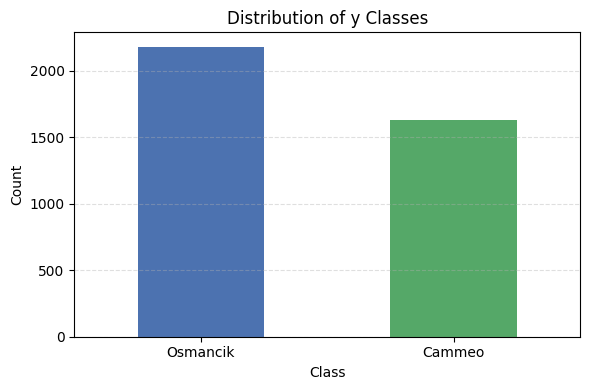

Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


In [12]:
class_counts = y.iloc[:, 0].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#4C72B0","#55A868"])
plt.title("Distribution of y Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(class_counts)

In [13]:
# Ensure X and y are pandas DataFrames
X = pd.DataFrame(X)
y = pd.DataFrame(y)

print(type(X), X.shape)
print(type(y), y.shape)

<class 'pandas.DataFrame'> (3810, 7)
<class 'pandas.DataFrame'> (3810, 1)


In [14]:
# Distribution of features in X and relationship with target y
if "df_plot" in globals():
    data = df_plot.copy()
else:
    X_plot_local = X.copy()
    X_plot_local.columns = [
        c[0] if isinstance(c, tuple) and len(c) > 0 else str(c) for c in X_plot_local.columns
    ]
    y_series_local = y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y
    data = X_plot_local.copy()
    data["Class"] = y_series_local.values

# Select usable numeric feature columns
if "feature_cols" in globals():
    features = [c for c in feature_cols if c in data.columns]
else:
    features = data.select_dtypes(include=np.number).columns.tolist()

data = data.dropna(subset=features + ["Class"])

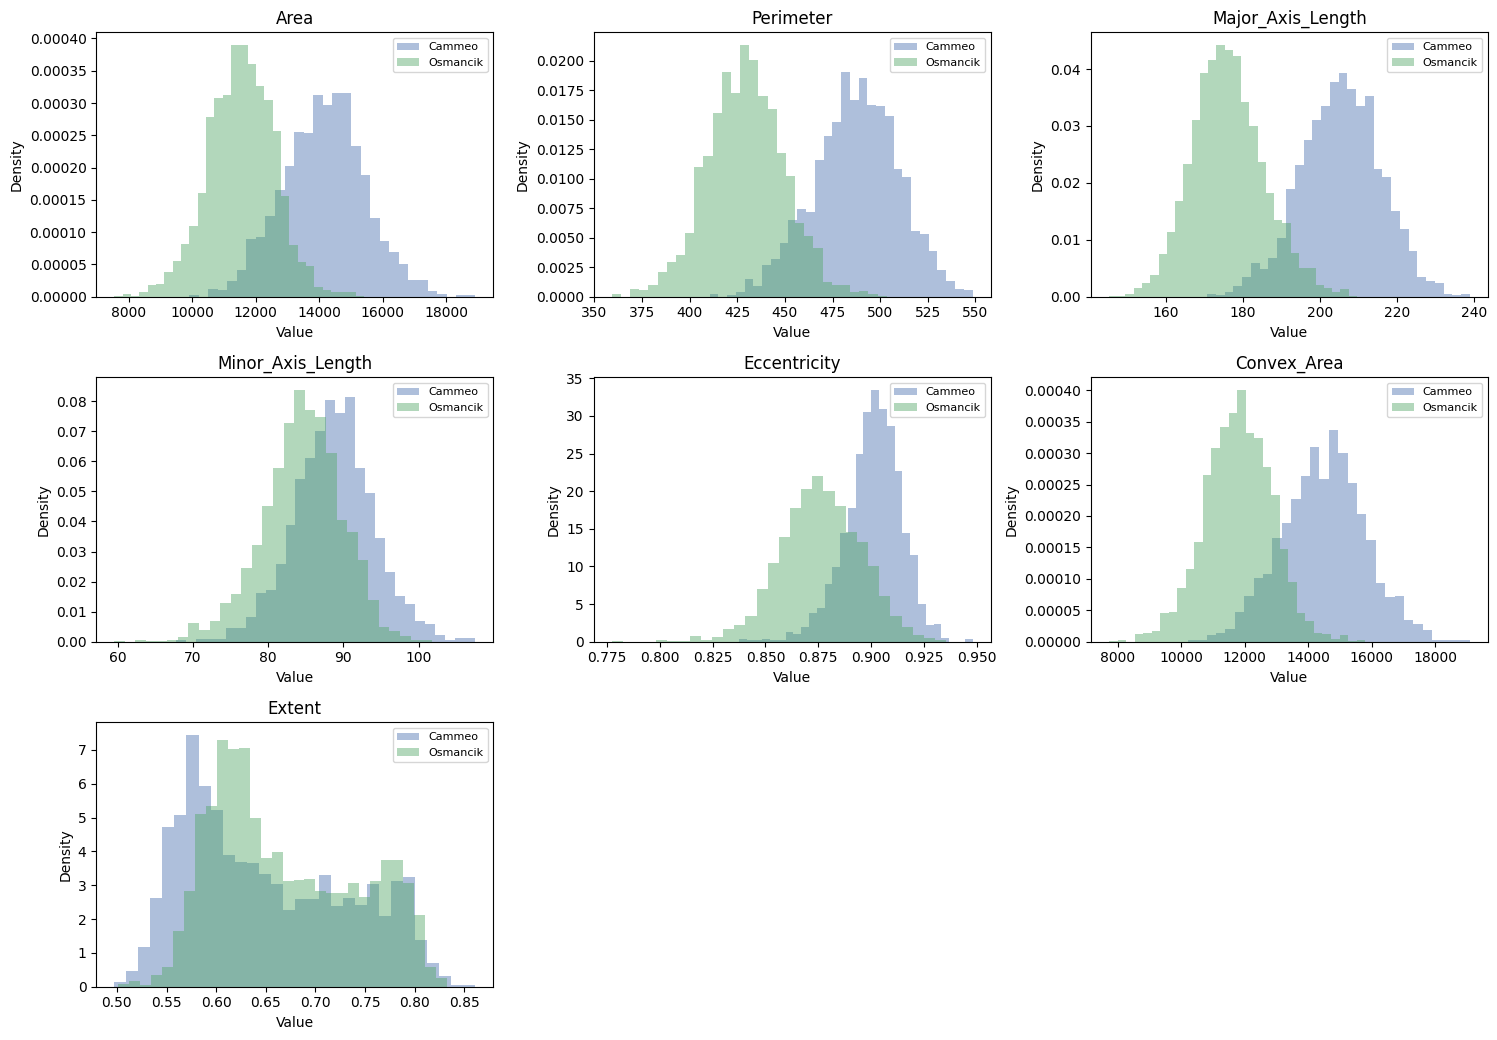

In [15]:

# Feature distributions by class (overlaid histograms)
n_features = len(features)
ncols = 3
nrows = (n_features + ncols - 1) // ncols
palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
classes = sorted(data["Class"].unique())

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(features):
    for cls, color in zip(classes, palette):
        vals = data.loc[data["Class"] == cls, col]
        axes[i].hist(vals, bins=30, density=True, alpha=0.45, label=cls, color=color)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

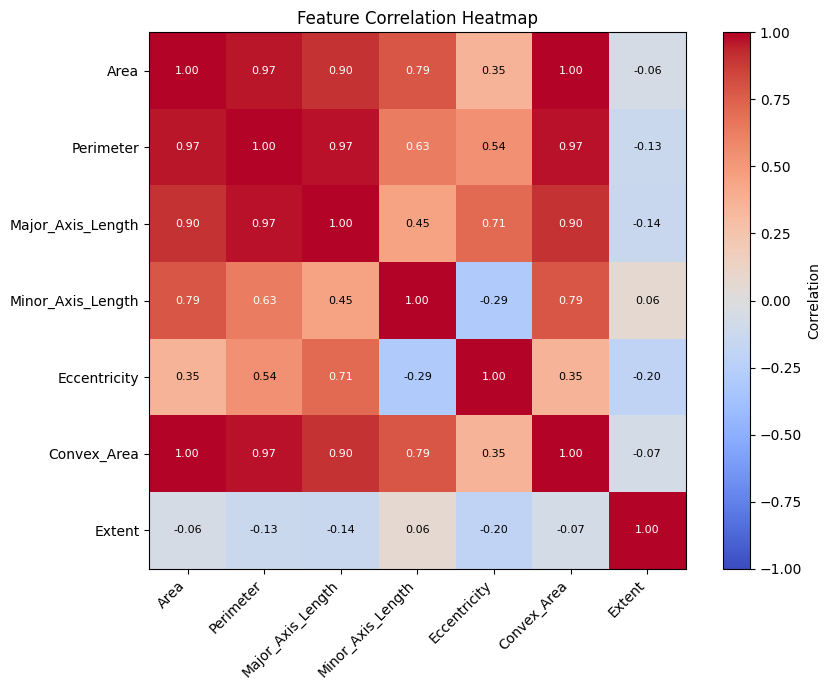

In [16]:
# Correlation heatmap for features of X
corr_matrix = X.corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr_matrix, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")
plt.title("Feature Correlation Heatmap")
ticks = np.arange(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha="right")
plt.yticks(ticks, corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center",
                 fontsize=8, color="white" if abs(corr_matrix.iloc[i, j]) > 0.6 else "black")

plt.tight_layout()
plt.show()

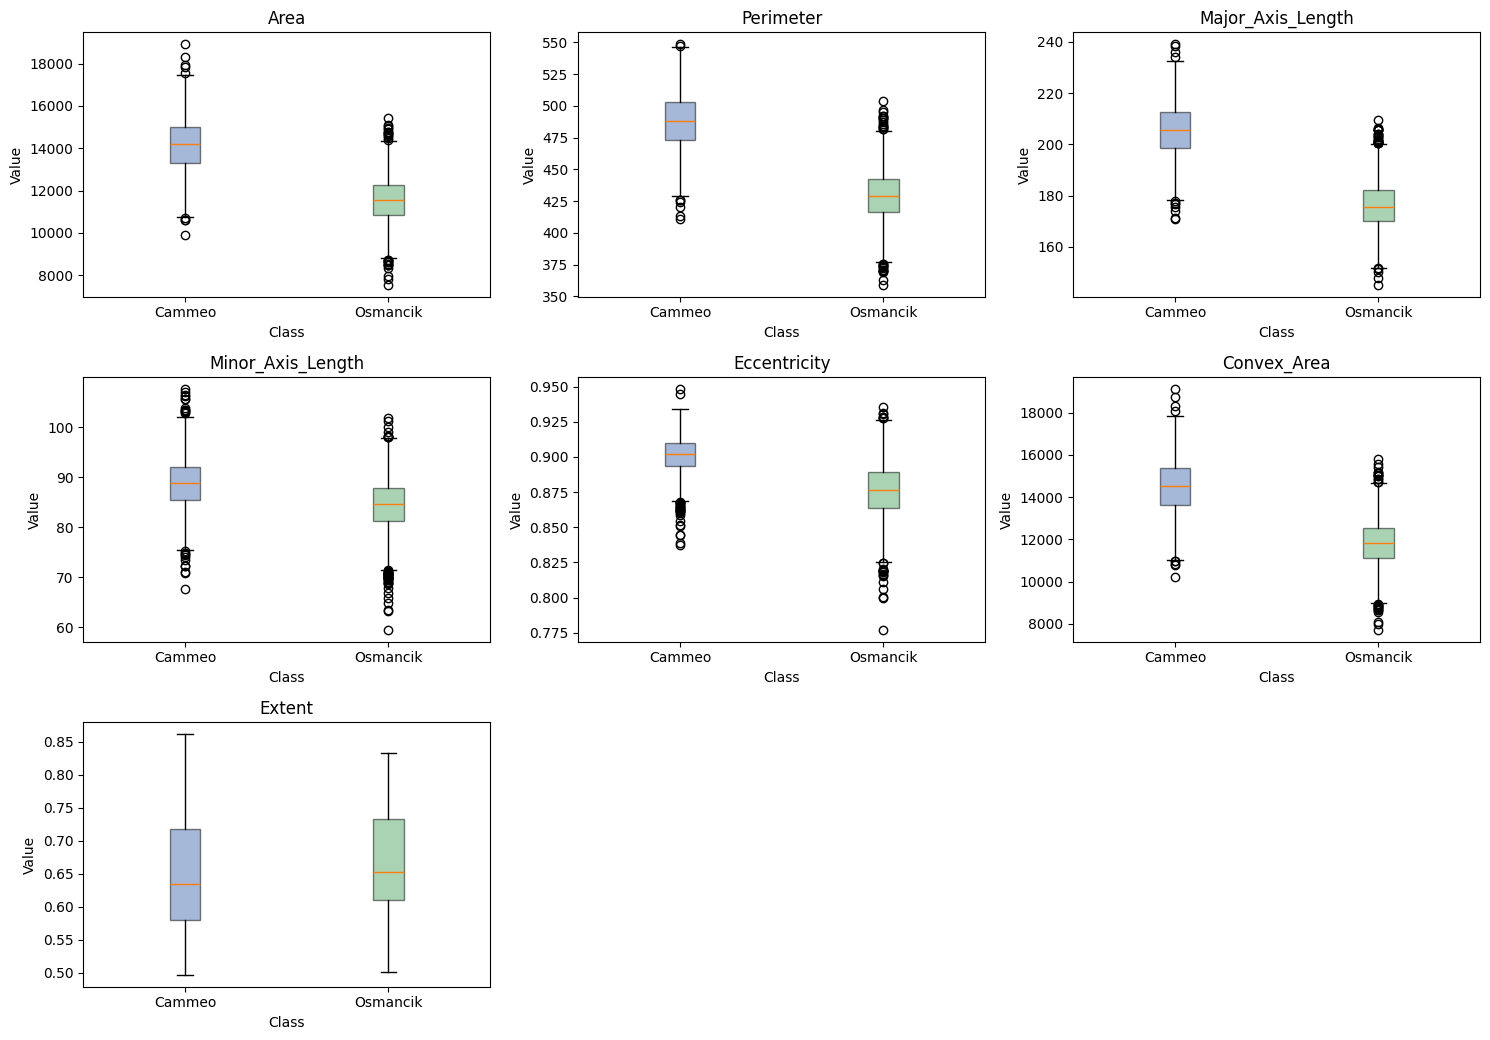

In [17]:
# Relationship with target: boxplots per class
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(features):
    grouped = [data.loc[data["Class"] == cls, col].values for cls in classes]
    bp = axes[i].boxplot(grouped, tick_labels=classes, patch_artist=True)
    for patch, color in zip(bp["boxes"], palette[:len(classes)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Class-wise summary statistics
print(data.groupby("Class")[features].agg(["mean", "std"]).round(3))

               Area           Perimeter         Major_Axis_Length          \
               mean       std      mean     std              mean     std   
Class                                                                       
Cammeo    14162.892  1286.771   487.439  22.182           205.479  10.334   
Osmancik  11549.783  1041.909   429.416  20.154           176.288   9.362   

         Minor_Axis_Length        Eccentricity        Convex_Area            \
                      mean    std         mean    std        mean       std   
Class                                                                         
Cammeo              88.768  5.350        0.901  0.013   14494.427  1309.419   
Osmancik            84.479  5.303        0.876  0.019   11799.586  1062.804   

         Extent         
           mean    std  
Class                   
Cammeo    0.651  0.082  
Osmancik  0.670  0.072  


In [19]:
print("Total NaNs in X:", X.isna().sum().sum())

Total NaNs in X: 0


In [20]:
# Dataset preprocessing, model training, and evaluation
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Logistic Regression Accuracy: 0.9291
Predicition inputs (first 5 rows of x_test_scaled):
[[-1.22339268e-01  1.59575862e-01 -5.93718740e-02  1.49823097e-01
  -5.71726874e-02  1.46966974e-03 -9.73364934e-01]
 [-1.41908052e-01 -4.71779010e-01 -5.03448103e-01  4.35926170e-01
  -8.19160463e-01 -1.91000179e-01 -3.36382460e-01]
 [ 1.22270534e-01 -1.33520676e-01 -3.91430001e-01  8.73443507e-01
  -1.05201256e+00  1.19869490e-01 -1.79765763e-01]
 [ 2.50618735e-01  5.35512658e-01  8.03474866e-01 -5.39540971e-01
   1.20170774e+00  2.20312939e-01  1.44956769e+00]
 [-1.32121507e+00 -1.24280026e+00 -8.69517039e-01 -1.64652568e+00
   4.65005015e-01 -1.36265337e+00 -1.15396661e+00]]
Logistic Regression Predictions (first 5): ['Osmancik' 'Osmancik' 'Osmancik' 'Cammeo' 'Osmancik']
Classification Report:
              precision    recall  f1-score   support

      Cammeo       0.92      0.93      0.92       350
    Osmancik       0.94      0.93      0.93       412

    accuracy                           0

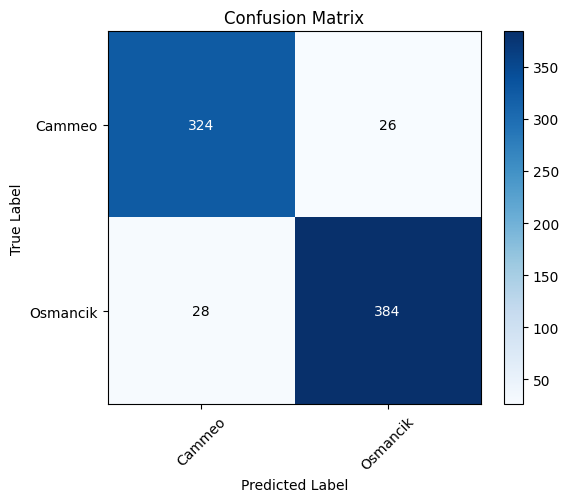

In [21]:
# Logistic Regression
logReg = LogisticRegression(max_iter=1000, random_state=42)
logReg.fit(x_train_scaled, y_train.values.ravel())
y_pred = logReg.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

#Logistic Regression Predictions (first 5):
print("Predicition inputs (first 5 rows of x_test_scaled):")
print(x_test_scaled[:5])
print("Logistic Regression Predictions (first 5):", y_pred[:5])

# Additional evaluation metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

Random Forest Accuracy: 0.9252
Random Forest Classification Report:
              precision    recall  f1-score   support

      Cammeo       0.92      0.91      0.92       350
    Osmancik       0.93      0.93      0.93       412

    accuracy                           0.93       762
   macro avg       0.92      0.92      0.92       762
weighted avg       0.93      0.93      0.93       762



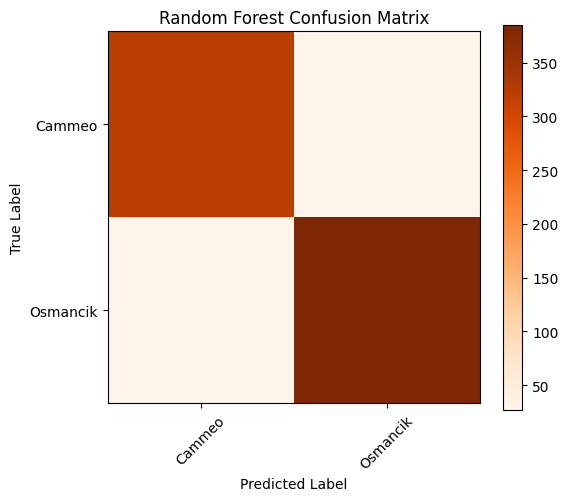

In [22]:
# Random forrest classifier
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(x_train_scaled, y_train.values.ravel())
y_pred_rf = rf_clf.predict(x_test_scaled)

# Align y_pred_rf label type with y_test before evaluation
y_test = y_test.iloc[:, 0] if isinstance(y_test, pd.DataFrame) else y_test

if pd.api.types.is_numeric_dtype(y_test):
    class_to_num = {cls: i for i, cls in enumerate(classes)} if "classes" in globals() else {"Cammeo": 0, "Osmancik": 1}
    y_pred_rf = pd.Series(y_pred_rf, index=y_test.index).map(class_to_num).to_numpy()
else:
    y_test = y_test.astype(str)
    y_pred_rf = np.asarray(y_pred_rf).astype(str)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# Additional evaluation for Random Forest
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
plt.imshow(cm_rf, interpolation="nearest", cmap=plt.cm.Oranges)
plt.title("Random Forest Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

SVM Accuracy: 0.9370
SVM Classification Report:
              precision    recall  f1-score   support

      Cammeo       0.94      0.93      0.93       350
    Osmancik       0.94      0.95      0.94       412

    accuracy                           0.94       762
   macro avg       0.94      0.94      0.94       762
weighted avg       0.94      0.94      0.94       762



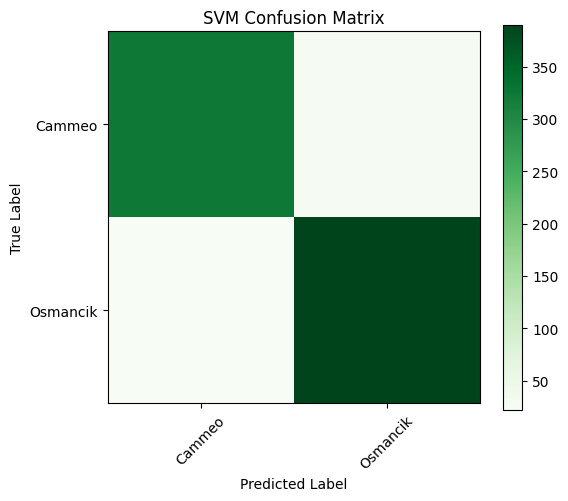

In [23]:
# SVM Classifier
from sklearn.svm import SVC
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(x_train_scaled, y_train.values.ravel())
y_pred_svm = svm_clf.predict(x_test_scaled)

# Align label types between y_test and y_pred_svm
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0]

if pd.api.types.is_numeric_dtype(y_test):
    num_to_class = {i: cls for i, cls in enumerate(classes)} if "classes" in globals() else {0: "Cammeo", 1: "Osmancik"}
    y_test = y_test.map(num_to_class)

y_test = y_test.astype(str)
y_pred_svm = np.asarray(y_pred_svm).astype(str)

# Evaluate SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f}")

# Additional evaluation for SVM
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
plt.imshow(cm_svm, interpolation="nearest", cmap=plt.cm.Greens)
plt.title("SVM Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

Neural Network Accuracy: 0.9291
Neural Network Classification Report:
              precision    recall  f1-score   support

      Cammeo       0.93      0.92      0.92       350
    Osmancik       0.93      0.94      0.93       412

    accuracy                           0.93       762
   macro avg       0.93      0.93      0.93       762
weighted avg       0.93      0.93      0.93       762



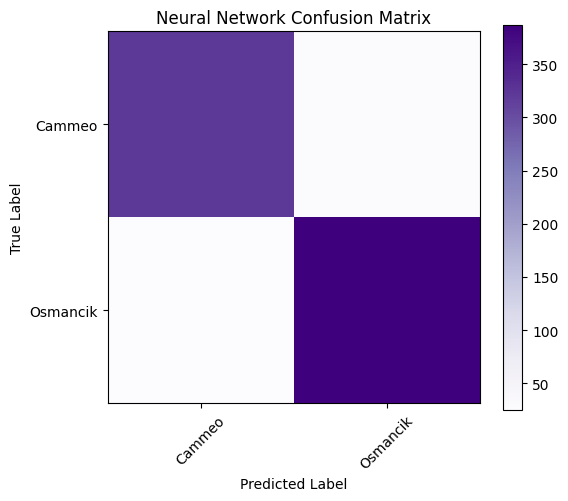

In [24]:
# Neural Network Classifier
from sklearn.neural_network import MLPClassifier
nn_clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
nn_clf.fit(x_train_scaled, y_train.values.ravel())
y_pred_nn = nn_clf.predict(x_test_scaled)

# Align label types between y_test and y_pred_nn
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0]
if pd.api.types.is_numeric_dtype(y_test):
    num_to_class = {i: cls for i, cls in enumerate(classes)} if "classes" in globals() else {0: "Cammeo", 1: "Osmancik"}
    y_test = y_test.map(num_to_class)
y_test = y_test.astype(str)
y_pred_nn = np.asarray(y_pred_nn).astype(str)

# Evaluate Neural Network
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"Neural Network Accuracy: {accuracy_nn:.4f}")

# Additional evaluation for Neural Network
print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))

# Neural Network Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 5))
plt.imshow(cm_nn, interpolation="nearest", cmap=plt.cm.Purples)
plt.title("Neural Network Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

In [ ]:
# Install the cuda version of pytorch for GPU acceleration (if available)
# pip install --no-cache-dir torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
# subprocess.check_call(
#     [sys.executable, "-m", "pip", "install", " torch", "torchvision", "torchaudio", "--index-url", "https://download.pytorch.org/whl/cu124"]
#     )

In [ ]:
# Pytorch neural network classifier
import torch
import torch.cuda
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np
from tqdm import tqdm
from collections import OrderedDict
import copy

# Verify CUDA is available
assert torch.cuda.is_available(), "CUDA is not available – install a CUDA-enabled PyTorch build"
device = torch.device("cuda")
print(f"Using device: {device}  ({torch.cuda.get_device_name(0)})")
torch.cuda.empty_cache()


# Model Definition
class Classifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x):
        return self.net(x)


# Hyperparameters
INPUT_SIZE = x_train_scaled.shape[1]
HIDDEN_SIZE = 4
NUM_CLASSES = len(classes)
LEARNING_RATE = 0.001
EPOCHS = 500
BATCH_SIZE = 16
PATIENCE = 100  # early stopping: stop after this many epochs with no val acc improvement

# Encode string labels to integers
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train.values.ravel())
y_test_encoded = le.transform(y_test.values.ravel())

# Ensure NumPy arrays have explicit dtypes before tensor conversion
x_train_np = np.asarray(x_train_scaled, dtype=np.float32)
x_test_np = np.asarray(x_test_scaled, dtype=np.float32)
y_train_np = np.asarray(y_train_encoded, dtype=np.int64)
y_test_np = np.asarray(y_test_encoded, dtype=np.int64)

# Move ALL data to GPU upfront (avoids per-batch CPU→GPU transfers)
x_train_tensor = torch.from_numpy(x_train_np).to(device)
y_train_tensor = torch.from_numpy(y_train_np).to(device)
x_test_tensor = torch.from_numpy(x_test_np).to(device)
y_test_tensor = torch.from_numpy(y_test_np).to(device)

# Datasets and DataLoaders (data is already on GPU, no pin_memory needed)
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(x_test_tensor, y_test_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model, Loss, Optimizer
model = Classifier(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

# Early stopping state
best_val_acc = 0.0
best_model_state = None
epochs_without_improvement = 0

# Training & Validation Loop
progress_bar = tqdm(range(EPOCHS), desc="Training", unit="epoch")
for epoch in progress_bar:
    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    train_acc = train_correct / train_total * 100
    val_acc = val_correct / val_total * 100
    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total

    # Early Stopping & Best Model Checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    progress_bar.set_postfix(OrderedDict(
        TrLoss=f"{avg_train_loss:.4f}",
        TrAcc=f"{train_acc:.1f}%",
        VlLoss=f"{avg_val_loss:.4f}",
        VlAcc=f"{val_acc:.1f}%",
        Best=f"{best_val_acc:.1f}%",
    ), refresh=True)

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch + 1} — no val acc improvement for {PATIENCE} epochs")
        break

# Restore the best model
model.load_state_dict(best_model_state)
print(f"Restored best model with Val Acc: {best_val_acc:.1f}%")

Using device: cuda  (NVIDIA RTX 3000 Ada Generation Laptop GPU)


Training:  21%|██        | 105/500 [00:31<01:57,  3.37epoch/s, TrLoss=0.1867, TrAcc=92.8%, VlLoss=0.1727, VlAcc=92.7%, Best=93.4%]


Early stopping at epoch 106 — no val acc improvement for 100 epochs
Restored best model with Val Acc: 93.4%


PyTorch NN Predictions (first 5): ['Osmancik' 'Osmancik' 'Osmancik' 'Cammeo' 'Osmancik']
PyTorch NN Predictions (first 5): ['Osmancik' 'Osmancik' 'Osmancik' 'Cammeo' 'Osmancik']

  PyTorch Neural Network — Evaluation Summary
  Overall Accuracy : 0.9344
  Macro Precision  : 0.9350
  Macro Recall     : 0.9329
  Macro F1-Score   : 0.9338

              precision    recall  f1-score   support

      Cammeo       0.94      0.91      0.93       350
    Osmancik       0.93      0.95      0.94       412

    accuracy                           0.93       762
   macro avg       0.94      0.93      0.93       762
weighted avg       0.93      0.93      0.93       762



C:\Users\mikka\AppData\Local\Temp\ipykernel_27896\2533065844.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


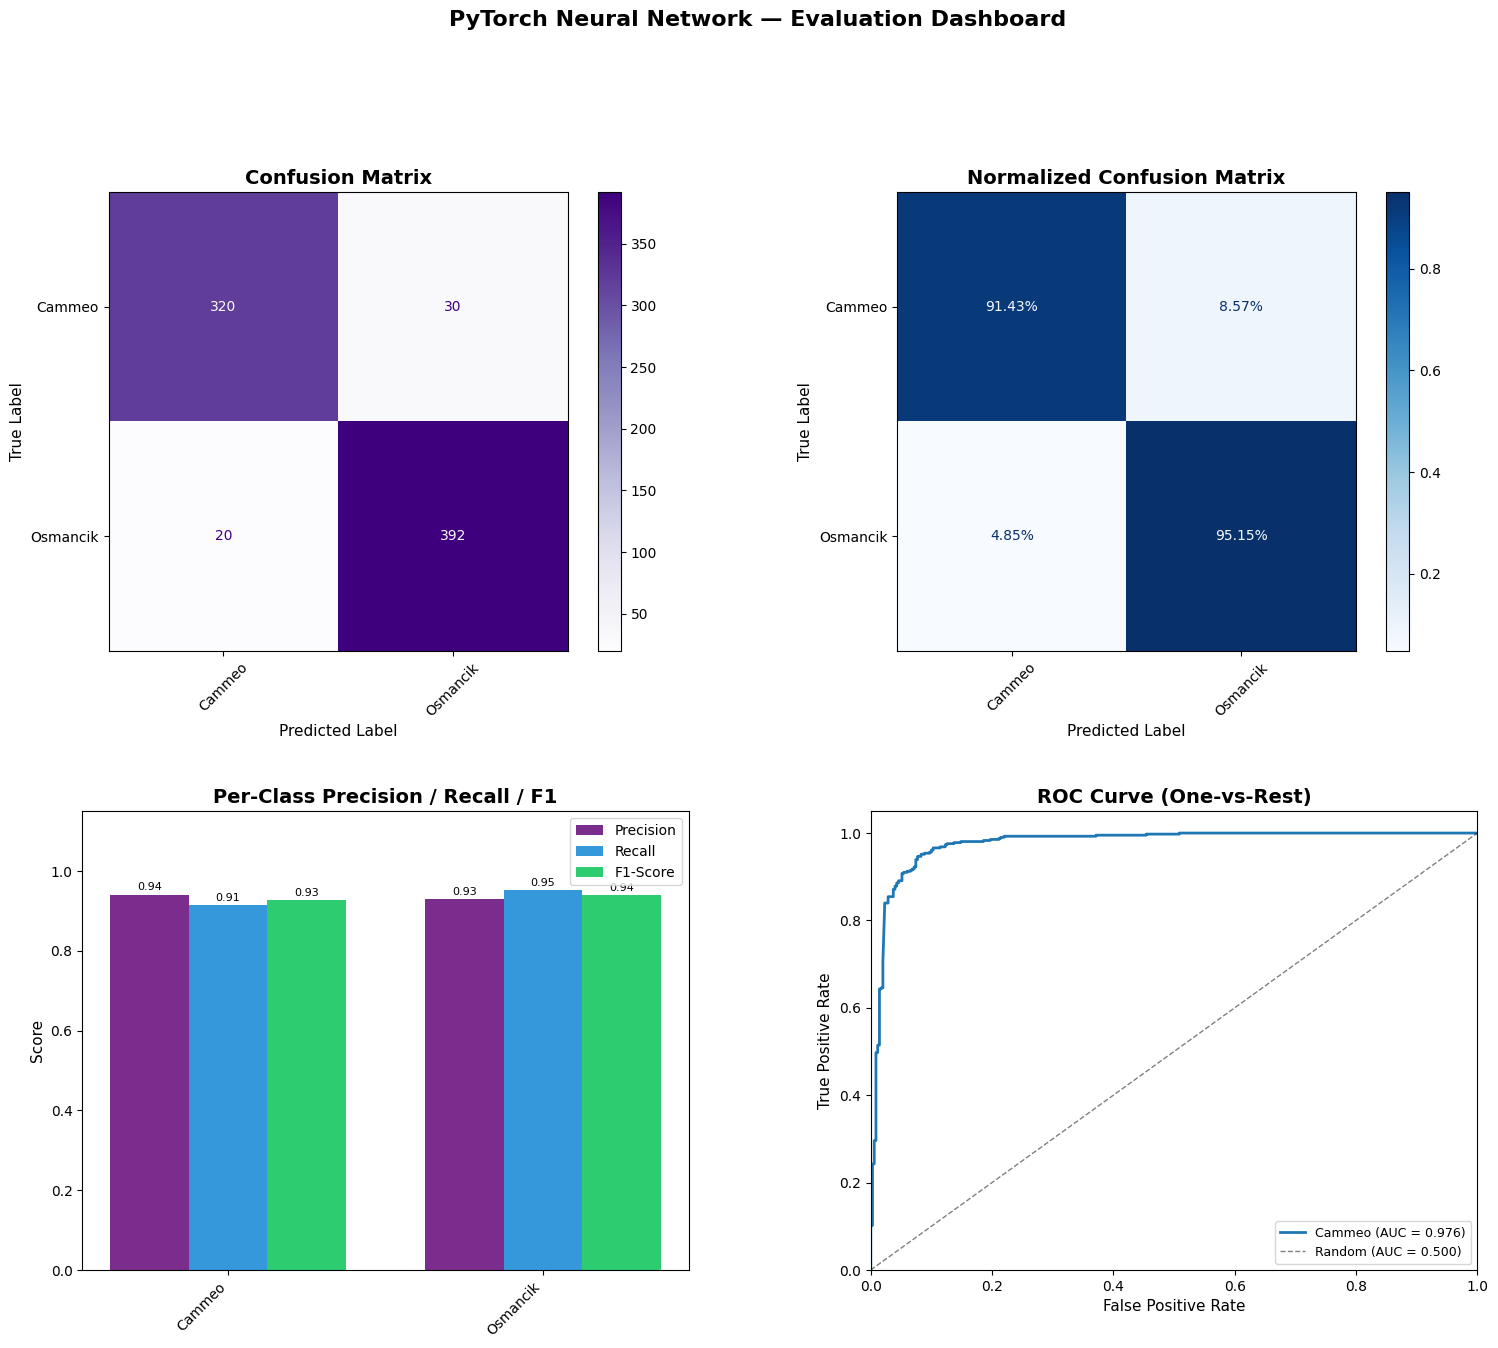

PyTorch Neural Network Accuracy: 0.9344
PyTorch Neural Network Classification Report:
              precision    recall  f1-score   support

      Cammeo       0.94      0.91      0.93       350
    Osmancik       0.93      0.95      0.94       412

    accuracy                           0.93       762
   macro avg       0.94      0.93      0.93       762
weighted avg       0.93      0.93      0.93       762



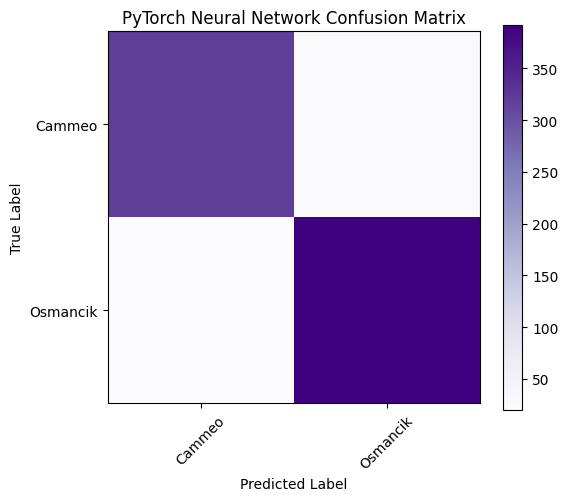

In [42]:
# Test PyTorch model predictions
model.eval()
with torch.no_grad():
    test_outputs = model(x_test_tensor)
    _, test_predicted = torch.max(test_outputs, 1)

test_pred_cpu = test_predicted.cpu().numpy()
test_predicted_labels = le.inverse_transform(test_pred_cpu)

print("PyTorch NN Predictions (first 5):", test_predicted_labels[:5])
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve, auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

# Test PyTorch model predictions
model.eval()
with torch.no_grad():
    test_outputs = model(x_test_tensor)
    test_probs = torch.softmax(test_outputs, dim=1).cpu().numpy()
    _, test_predicted = torch.max(test_outputs, 1)

test_pred_cpu = test_predicted.cpu().numpy()
test_predicted_labels = le.inverse_transform(test_pred_cpu)

print("PyTorch NN Predictions (first 5):", test_predicted_labels[:5])

# Overall Metrics
accuracy_nn_torch = accuracy_score(y_test_encoded, test_pred_cpu)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_encoded, test_pred_cpu, average=None
)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test_encoded, test_pred_cpu, average="macro"
)

print(f"\n{'='*60}")
print(f"  PyTorch Neural Network — Evaluation Summary")
print(f"{'='*60}")
print(f"  Overall Accuracy : {accuracy_nn_torch:.4f}")
print(f"  Macro Precision  : {macro_precision:.4f}")
print(f"  Macro Recall     : {macro_recall:.4f}")
print(f"  Macro F1-Score   : {macro_f1:.4f}")
print(f"{'='*60}\n")
print(classification_report(y_test_encoded, test_pred_cpu, target_names=le.classes_))

# Figure with 4 subplots
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# Confusion Matrix with annotated values
ax1 = fig.add_subplot(gs[0, 0])
cm_nn_torch = confusion_matrix(y_test_encoded, test_pred_cpu)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn_torch, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Purples, ax=ax1, colorbar=True, values_format="d")
ax1.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
ax1.set_xlabel("Predicted Label", fontsize=11)
ax1.set_ylabel("True Label", fontsize=11)
ax1.tick_params(axis="x", rotation=45)

# Normalized Confusion Matrix (percentages)
ax2 = fig.add_subplot(gs[0, 1])
cm_normalized = cm_nn_torch.astype("float") / cm_nn_torch.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=le.classes_)
disp_norm.plot(cmap=plt.cm.Blues, ax=ax2, colorbar=True, values_format=".2%")
ax2.set_title("Normalized Confusion Matrix", fontsize=14, fontweight="bold")
ax2.set_xlabel("Predicted Label", fontsize=11)
ax2.set_ylabel("True Label", fontsize=11)
ax2.tick_params(axis="x", rotation=45)

# Per-Class Precision, Recall, F1 Bar Chart
ax3 = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(le.classes_))
bar_width = 0.25
bars1 = ax3.bar(x_pos - bar_width, precision, bar_width, label="Precision", color="#7b2d8e")
bars2 = ax3.bar(x_pos, recall, bar_width, label="Recall", color="#3498db")
bars3 = ax3.bar(x_pos + bar_width, f1, bar_width, label="F1-Score", color="#2ecc71")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(le.classes_, rotation=45, ha="right")
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score", fontsize=11)
ax3.set_title("Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax3.legend(loc="upper right")

# Annotate bar values
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax3.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

# ROC Curve (One-vs-Rest per class)
ax4 = fig.add_subplot(gs[1, 1])
y_test_bin = label_binarize(y_test_encoded, classes=np.arange(NUM_CLASSES))
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
    if y_test_bin.shape[1] == 1:
        # Binary case: use probabilities of class 1
        fpr, tpr, _ = roc_curve(y_test_bin[:, 0], test_probs[:, 1])
        roc_auc = auc(fpr, tpr)
        ax4.plot(fpr, tpr, color=color, lw=2,
                 label=f"{cls_name} (AUC = {roc_auc:.3f})")
        break
    else:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax4.plot(fpr, tpr, color=color, lw=2,
                 label=f"{cls_name} (AUC = {roc_auc:.3f})")
ax4.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC = 0.500)")
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel("False Positive Rate", fontsize=11)
ax4.set_ylabel("True Positive Rate", fontsize=11)
ax4.set_title("ROC Curve (One-vs-Rest)", fontsize=14, fontweight="bold")
ax4.legend(loc="lower right", fontsize=9)

plt.suptitle("PyTorch Neural Network — Evaluation Dashboard",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Evaluate PyTorch model (compare encoded integer labels)
accuracy_nn_torch = accuracy_score(y_test_encoded, test_pred_cpu)
print(f"PyTorch Neural Network Accuracy: {accuracy_nn_torch:.4f}")
print("PyTorch Neural Network Classification Report:")
print(classification_report(y_test_encoded, test_pred_cpu, target_names=le.classes_))

# PyTorch Confusion Matrix
cm_nn_torch = confusion_matrix(y_test_encoded, test_pred_cpu)
plt.figure(figsize=(6, 5))
plt.imshow(cm_nn_torch, interpolation="nearest", cmap=plt.cm.Purples)
plt.title("PyTorch Neural Network Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()